In [1]:
# Reproducibility Seed Setup
import os
import random
import numpy as np
import torch
from transformers import set_seed

SEED = 3180

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
set_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
print("Global random seed set:", SEED)

2026-03-10 12:38:03.726493: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 12:38:06.738688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-10 12:38:07.798837: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-10 12:38:08.165239: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-10 12:38:10.953545: I tensorflow/core/platform/cpu_feature_guar

✅ Global random seed set: 3180


In [2]:
import sys, site, platform
print("PY:", platform.python_version())
print("EXE:", sys.executable)
print("USER_SITE:", site.getusersitepackages())

PY: 3.11.6
EXE: /common/software/install/manual/jupyter_kernels/DeepLearning/bin/python
USER_SITE: /users/4/volko028/.local/lib/python3.11/site-packages


In [3]:
# !python -m pip install torch torchvision torchaudio transformers wfdb scipy

In [4]:
# !"{sys.executable}" -m pip install -U --no-cache-dir torch torchvision torchaudio transformers wfdb scipy

In [5]:
import pandas as pd
import ast
import os
import numpy as np
import wfdb
from scipy.signal import resample
import torch
from torch.utils.data import Dataset, DataLoader, random_split

In [6]:
use_cols = ["ecg_paths", "outcome_hospitalization"]

df_train = pd.read_csv("mv_train_DISPOSITION.csv", usecols=use_cols)
df_test = pd.read_csv("mv_test_DISPOSITION.csv", usecols=use_cols)
df_val = pd.read_csv("mv_val_DISPOSITION.csv", usecols=use_cols)

df_val

,outcome_hospitalization,ecg_paths
0,True,['files/p1550/p15500541/s46936583/46936583']
1,True,['files/p1700/p17002060/s48930626/48930626']
2,True,['files/p1257/p12578079/s47741864/47741864']
3,True,['files/p1029/p10291949/s44662350/44662350']
4,True,['files/p1290/p12909383/s40566170/40566170']
...,...,...
18981,True,['files/p1768/p17684445/s44702686/44702686']
18982,True,['files/p1351/p13514137/s40858687/40858687']
18983,True,['files/p1852/p18529406/s40525850/40525850']
18984,False,['files/p1675/p16754064/s49818873/49818873']


In [8]:
df_val["ecg_paths"][0]

"['files/p1550/p15500541/s46936583/46936583']"

In [9]:
# Turn "['files/...', 'files/...']" strings back into Python lists
df_train["ecg_paths"] = df_train["ecg_paths"].apply(ast.literal_eval)

# Make labels float 0/1
df_train["outcome_hospitalization"] = df_train["outcome_hospitalization"].astype(int)
df_train = df_train[["ecg_paths", "outcome_hospitalization"]]
df_train.head()

# Turn "['files/...', 'files/...']" strings back into Python lists
df_test["ecg_paths"] = df_test["ecg_paths"].apply(ast.literal_eval)

# Make labels float 0/1
df_test["outcome_hospitalization"] = df_test["outcome_hospitalization"].astype(int)
df_test = df_test[["ecg_paths", "outcome_hospitalization"]]
df_test.head()

# Turn "['files/...', 'files/...']" strings back into Python lists
df_val["ecg_paths"] = df_val["ecg_paths"].apply(ast.literal_eval)

# Make labels float 0/1
df_val["outcome_hospitalization"] = df_val["outcome_hospitalization"].astype(int)
df_val = df_val[["ecg_paths", "outcome_hospitalization"]]
df_val.head()

,ecg_paths,outcome_hospitalization
0,[files/p1550/p15500541/s46936583/46936583],1
1,[files/p1700/p17002060/s48930626/48930626],1
2,[files/p1257/p12578079/s47741864/47741864],1
3,[files/p1029/p10291949/s44662350/44662350],1
4,[files/p1290/p12909383/s40566170/40566170],1


In [10]:
BASE_DIR = "/projects/standard/xie00469/shared/mimic-iv-ecg"

class HospitalizationECGDataset(Dataset):
    def __init__(self, df, base_dir, seconds=5, target_fs=100, lead=0):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.seconds = seconds
        self.target_fs = target_fs
        self.lead = lead
        self.target_len = seconds * target_fs

    def __len__(self):
        return len(self.df)
    
    def _load_last_ecg(self, rel_paths):
        for rel in reversed(rel_paths):
            rec_path = os.path.join(self.base_dir, rel)

            if rec_path.endswith(".hea") or rec_path.endswith(".dat"):
                rec_path = os.path.splitext(rec_path)[0]

            try:
                record = wfdb.rdrecord(rec_path)

                sig = record.p_signal[:, self.lead].astype(np.float32)
                fs = float(record.fs)

                sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)

                return sig, fs

            except Exception:
                continue

        return None, None

    def _resample_and_crop(self, sig, fs):
        if fs != self.target_fs:
            new_len = int(len(sig) * self.target_fs / fs)
            sig = resample(sig, new_len).astype(np.float32)
            sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)

        if len(sig) >= self.target_len:
            sig = sig[-self.target_len:]
        else:
            pad = self.target_len - len(sig)
            sig = np.pad(sig, (pad, 0), mode="constant")

        mean = sig.mean()
        std = sig.std()
        if std > 0:
            sig = (sig - mean) / std
        else:
            sig = sig - mean

        sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
        return sig.astype(np.float32)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        paths = row["ecg_paths"]
        label = float(row["outcome_hospitalization"])

        sig, fs = self._load_last_ecg(paths)

        if sig is None:
            sig = np.zeros(self.target_len, dtype=np.float32)
            fs = self.target_fs

        sig = self._resample_and_crop(sig, fs)

        x = torch.from_numpy(sig)
        y = torch.tensor(label, dtype=torch.float32)
        return x, y

In [11]:
seconds   = 10
target_fs = 250
BATCH_SIZE = 16

train_ds = HospitalizationECGDataset(df_train, BASE_DIR, seconds=seconds, target_fs=target_fs)
val_ds   = HospitalizationECGDataset(df_val,   BASE_DIR, seconds=seconds, target_fs=target_fs)
test_ds  = HospitalizationECGDataset(df_test,  BASE_DIR, seconds=seconds, target_fs=target_fs)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g_dl = torch.Generator()
g_dl.manual_seed(SEED)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=4,
    worker_init_fn=seed_worker,
    generator=g_dl,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=4,
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=4,
    worker_init_fn=seed_worker,
)

print("train rows:", len(df_train), "dataset:", len(train_ds))
print("val rows:", len(df_val), "dataset:", len(val_ds))
print("test rows:", len(df_test), "dataset:", len(test_ds))

train rows: 151891 dataset: 151891
val rows: 18986 dataset: 18986
test rows: 18987 dataset: 18987


In [12]:
# print(backbone.config)

In [13]:
from transformers import AutoModel
from torch.optim import AdamW
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

size = "base"
backbone = AutoModel.from_pretrained(
    f"Edoardo-BS/hubert-ecg-{size}",
    trust_remote_code=True
).to(device)

class HuBERT_ECG_Hosp(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        hidden = backbone.config.hidden_size

        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, input_values):
        outputs = self.backbone(input_values=input_values)
        last_hidden = outputs.last_hidden_state
        pooled = last_hidden.mean(dim=1)
        logits = self.head(pooled).squeeze(-1)
        return logits

model = HuBERT_ECG_Hosp(backbone).to(device)

# Freeze backbone parameters
for p in model.backbone.parameters():
    p.requires_grad = False

optimizer = AdamW(model.head.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [14]:
from tqdm import tqdm

MAX_NORM = 1.0

def run_epoch(dl, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_n = 0
    all_logits = []
    all_labels = []

    for i, (xb, yb) in enumerate(tqdm(dl, total=len(dl), desc="Train" if train else "Val")):
        
        if torch.isnan(xb).any() or torch.isinf(xb).any():
            print("Found NaNs/Infs in input at batch", i)
        if torch.isnan(yb).any() or torch.isinf(yb).any():
            print("Found NaNs/Infs in labels at batch", i)

        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)
            
            if torch.isnan(loss):
                print("NaN loss at batch", i)
                print("logits stats:", logits.min().item(), logits.max().item())
                continue

            if train:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / total_n
    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    preds = (torch.sigmoid(all_logits) >= 0.5).float()
    acc = (preds == all_labels).float().mean().item()

    return avg_loss, acc


N_EPOCHS = 10

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

Train:   0%|          | 0/9493 [00:00<?, ?it/s]/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
/users/4/volko028/.local/lib/python3.11/site-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterminist

Epoch 1: train_loss=0.6204, train_acc=0.673, val_loss=0.6002, val_acc=0.679


Val: 100%|██████████| 1187/1187 [04:56<00:00,  4.00it/s]


Epoch 2: train_loss=0.6122, train_acc=0.677, val_loss=0.6023, val_acc=0.679


Val: 100%|██████████| 1187/1187 [04:27<00:00,  4.44it/s]


...

Epoch 8: train_loss=0.6044, train_acc=0.678, val_loss=0.6003, val_acc=0.682


Val: 100%|██████████| 1187/1187 [03:20<00:00,  5.92it/s]


Epoch 9: train_loss=0.6049, train_acc=0.678, val_loss=0.5968, val_acc=0.683


Val: 100%|██████████| 1187/1187 [03:20<00:00,  5.93it/s]

Epoch 10: train_loss=0.6046, train_acc=0.678, val_loss=0.5996, val_acc=0.677


Confusion Matrix Eval:   0%|          | 0/1187 [00:00<?, ?it/s]/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
Confusion Matrix Eval: 100%|██████████| 1187/1187 [03:18<00:00,  5.97it/s]


Confusion Matrix:
 [[  226  5908]
 [  218 12634]]


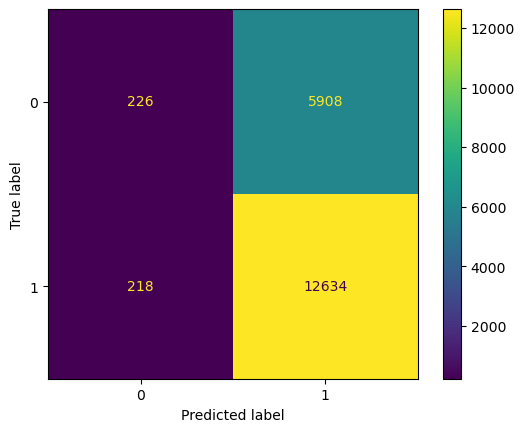

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Run evaluation over validation set
model.eval()
all_logits = []
all_labels = []

with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="Confusion Matrix Eval"):
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        all_logits.append(logits.cpu())
        all_labels.append(yb.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

preds = (torch.sigmoid(all_logits) >= 0.5).float()

cm = confusion_matrix(all_labels.numpy(), preds.numpy())
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [16]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import numpy as np

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# Compute ROC-AUC
auc = roc_auc_score(all_labels, all_probs)
print("ROC-AUC:", auc)

# Find BEST THRESHOLD
fpr, tpr, thr = roc_curve(all_labels, all_probs)
best_idx = np.argmax(tpr - fpr)
best_th = thr[best_idx]
print("Best threshold:", best_th)

# Confusion matrix at BEST threshold
preds = (all_probs >= best_th).astype(int)
cm = confusion_matrix(all_labels, preds)
print("CM @ best_th:\n", cm)

/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)


ROC-AUC: 0.6495791266548282
Best threshold: 0.6705982
CM @ best_th:
 [[4102 2032]
 [5750 7102]]


In [17]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import numpy as np

def eval_with_metrics(loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    auc = roc_auc_score(all_labels, all_probs)
    print("ROC-AUC:", auc)

    fpr, tpr, thr = roc_curve(all_labels, all_probs)
    best_idx = np.argmax(tpr - fpr)
    best_th = thr[best_idx]
    print("Best threshold:", best_th)

    preds = (all_probs >= best_th).astype(int)
    cm = confusion_matrix(all_labels, preds)
    print("Confusion matrix @ best_th:\n", cm)
    return auc, best_th, cm


In [18]:
auc, best_th, cm = eval_with_metrics(val_loader)

/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)


ROC-AUC: 0.6495791266548282
Best threshold: 0.6705982
Confusion matrix @ best_th:
 [[4102 2032]
 [5750 7102]]


In [19]:
# --- UNFREEZE BACKBONE ---
for p in model.backbone.parameters():
    p.requires_grad = True

backbone_params = []
head_params = []
for name, p in model.named_parameters():
    if "backbone" in name:
        backbone_params.append(p)
    else:
        head_params.append(p)

optimizer = AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params, "lr": 5e-4},
])

criterion = nn.BCEWithLogitsLoss()

In [20]:
N_FINE_EPOCHS = 8
for epoch in range(1, N_FINE_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss,   val_acc   = run_epoch(val_loader,   train=False)
    print(f"[Fine] Epoch {epoch}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

Train:   0%|          | 0/9493 [00:00<?, ?it/s]/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
/users/4/volko028/.local/lib/python3.11/site-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterminist

[Fine] Epoch 1: train_loss=0.6007, train_acc=0.679, val_loss=0.5951, val_acc=0.672


Val: 100%|██████████| 1187/1187 [03:20<00:00,  5.92it/s]


[Fine] Epoch 2: train_loss=0.5904, train_acc=0.685, val_loss=0.5855, val_acc=0.686


Val: 100%|██████████| 1187/1187 [03:20<00:00,  5.93it/s]


...

[Fine] Epoch 6: train_loss=0.5762, train_acc=0.697, val_loss=0.5822, val_acc=0.694


Val: 100%|██████████| 1187/1187 [03:20<00:00,  5.92it/s]


[Fine] Epoch 7: train_loss=0.5721, train_acc=0.699, val_loss=0.5849, val_acc=0.692


Val: 100%|██████████| 1187/1187 [03:19<00:00,  5.95it/s]

[Fine] Epoch 8: train_loss=0.5681, train_acc=0.702, val_loss=0.5857, val_acc=0.697


Evaluating: 100%|██████████| 1187/1187 [03:18<00:00,  5.98it/s]


ROC-AUC: 0.6861
Best threshold: 0.7048
Confusion Matrix @ best threshold:
 [[3981 2153]
 [4847 8005]]


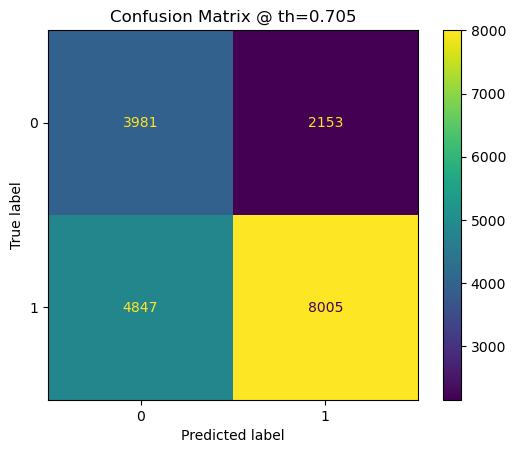

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def eval_with_metrics(loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Evaluating"):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # --- ROC-AUC ---
    auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC-AUC: {auc:.4f}")

    # --- BEST THRESHOLD ---
    fpr, tpr, thr = roc_curve(all_labels, all_probs)
    best_idx = np.argmax(tpr - fpr)
    best_th = thr[best_idx]
    print(f"Best threshold: {best_th:.4f}")

    # --- Confusion Matrix at best threshold ---
    preds = (all_probs >= best_th).astype(int)
    cm = confusion_matrix(all_labels, preds)
    print("Confusion Matrix @ best threshold:\n", cm)

    # Visualize
    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(f"Confusion Matrix @ th={best_th:.3f}")
    plt.show()

    return auc, best_th, cm

auc, best_th, cm = eval_with_metrics(val_loader)

In [23]:
def eval_with_metrics_and_save(loader, df_split, out_csv, threshold=None):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Evaluating"):
            xb = xb.to(device)
            logits = model(xb).squeeze(-1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC-AUC: {auc:.4f}")

    if threshold is None:
        fpr, tpr, thr = roc_curve(all_labels, all_probs)
        best_idx = np.argmax(tpr - fpr)
        threshold = thr[best_idx]
        print(f"Best threshold: {threshold:.4f}")
    else:
        print(f"Using threshold: {threshold:.4f}")

    preds = (all_probs >= threshold).astype(int)
    cm = confusion_matrix(all_labels, preds)
    print("Confusion Matrix:\n", cm)
    
    probs_df = pd.DataFrame({
        "sample_id": np.arange(len(all_probs)),
        "y_true": all_labels.astype(int),
        "pred_prob_ecg": all_probs
    })

    probs_df.to_csv(out_csv, index=False)
    print(f"Saved probabilities to: {out_csv}")

    return auc, threshold, cm, probs_df

# 

In [24]:
auc_val, best_th, cm_val, val_probs_df = eval_with_metrics_and_save(
    val_loader,
    df_val,
    out_csv="ecg_val_predictions_task5.csv"
)

auc_test, _, cm_test, test_probs_df = eval_with_metrics_and_save(
    test_loader,
    df_test,
    out_csv="ecg_test_predictions_task5.csv",
    threshold=best_th
)

Evaluating:   0%|          | 0/1187 [00:00<?, ?it/s]/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
Evaluating: 100%|██████████| 1187/1187 [03:18<00:00,  5.98it/s]


ROC-AUC: 0.6861
Best threshold: 0.7048
Confusion Matrix:
 [[3981 2153]
 [4847 8005]]
Saved probabilities to: ecg_val_predictions_task5.csv


Evaluating:   0%|          | 0/1187 [00:00<?, ?it/s]/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
Evaluating: 100%|██████████| 1187/1187 [03:18<00:00,  5.98it/s]


ROC-AUC: 0.6845
Using threshold: 0.7048
Confusion Matrix:
 [[4000 2202]
 [4866 7919]]
Saved probabilities to: ecg_test_predictions_task5.csv


Evaluating:   0%|          | 0/1187 [00:00<?, ?it/s]/users/4/volko028/.local/lib/python3.11/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  return F.linear(input, self.weight, self.bias)
Evaluating: 100%|██████████| 1187/1187 [03:19<00:00,  5.96it/s]


ROC-AUC: 0.6845
Best threshold: 0.6891
Confusion Matrix @ best threshold:
 [[3824 2378]
 [4462 8323]]


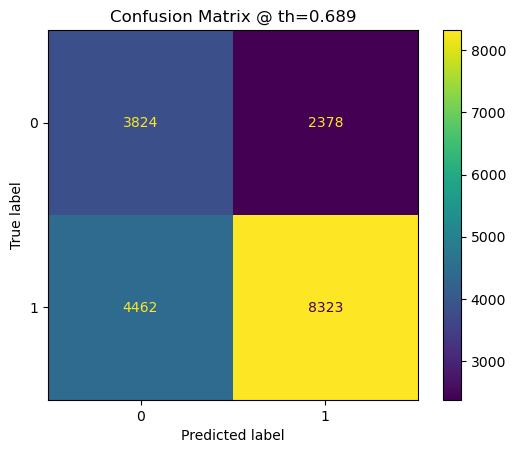

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def eval_with_metrics(loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Evaluating"):
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    # --- ROC-AUC ---
    auc = roc_auc_score(all_labels, all_probs)
    print(f"ROC-AUC: {auc:.4f}")

    # --- BEST THRESHOLD ---
    fpr, tpr, thr = roc_curve(all_labels, all_probs)
    best_idx = np.argmax(tpr - fpr)
    best_th = thr[best_idx]
    print(f"Best threshold: {best_th:.4f}")

    # --- Confusion Matrix at best threshold ---
    preds = (all_probs >= best_th).astype(int)
    cm = confusion_matrix(all_labels, preds)
    print("Confusion Matrix @ best threshold:\n", cm)

    # Visualize
    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)
    ax.set_title(f"Confusion Matrix @ th={best_th:.3f}")
    plt.show()

    return auc, best_th, cm

auc, best_th, cm = eval_with_metrics(test_loader)

AUPRC (Average Precision): 0.8075738249810293
PR-AUC: 0.8075521177126048


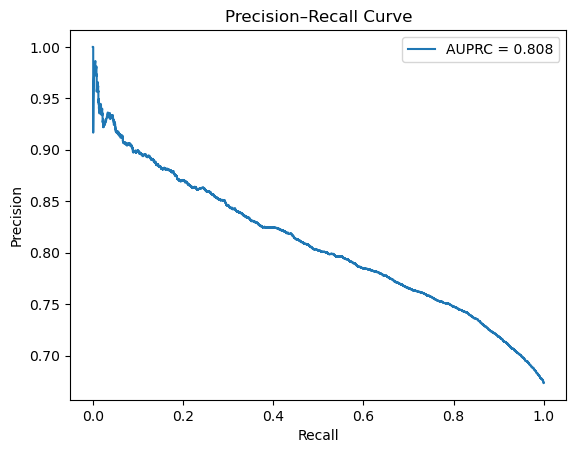

In [27]:
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

df = pd.read_csv("ecg_test_predictions_task5.csv")

y_true = df["y_true"]
y_prob = df["pred_prob_ecg"]

ap = average_precision_score(y_true, y_prob)
print("AUPRC (Average Precision):", ap)

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()